## Objectif du projet et structure du livrable

Ce notebook est structuré selon les livrables demandés par le professeur :

- **Livrable 1** : analyse exploratoire des données et préparation.
- **Livrable 2** : modélisation et optimisation.
- **Livrable 3** : visualisation des résultats et interprétation.
- **Livrable 4** : validation des résultats et documentation.

Le jeu de données est déséquilibré, ce qui motive le choix de métriques adaptées et une évaluation rigoureuse.


## Livrable 1 : Analyse exploratoire et préparation des données

Plan de cette étape :

1. Charger et inspecter le jeu de données.
2. Examiner les caractéristiques des variables et le déséquilibre de la cible.
3. Nettoyer les données, traiter les valeurs manquantes et enrichir les variables.
4. Normaliser les caractéristiques et préparer les jeux d'entraînement et de test.

Cette étape garantit que les données sont prêtes pour l'entraînement et que les modèles sont comparés sur une base saine.


In [1]:
# Imports and environment checks

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# Load data and initial inspection

DATA_PATH = "data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print('shape:', df.shape)
print('\nTarget distribution:')
if 'Class' in df.columns:
    print(df['Class'].value_counts(dropna=False))
else:
    print('No column named Class found — adjust target selection')

print('\nMissing values (top):')
print(df.isna().sum().sort_values(ascending=False).head(10))

# show a small sample
df.head()

shape: (284807, 31)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Missing values (top):
Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


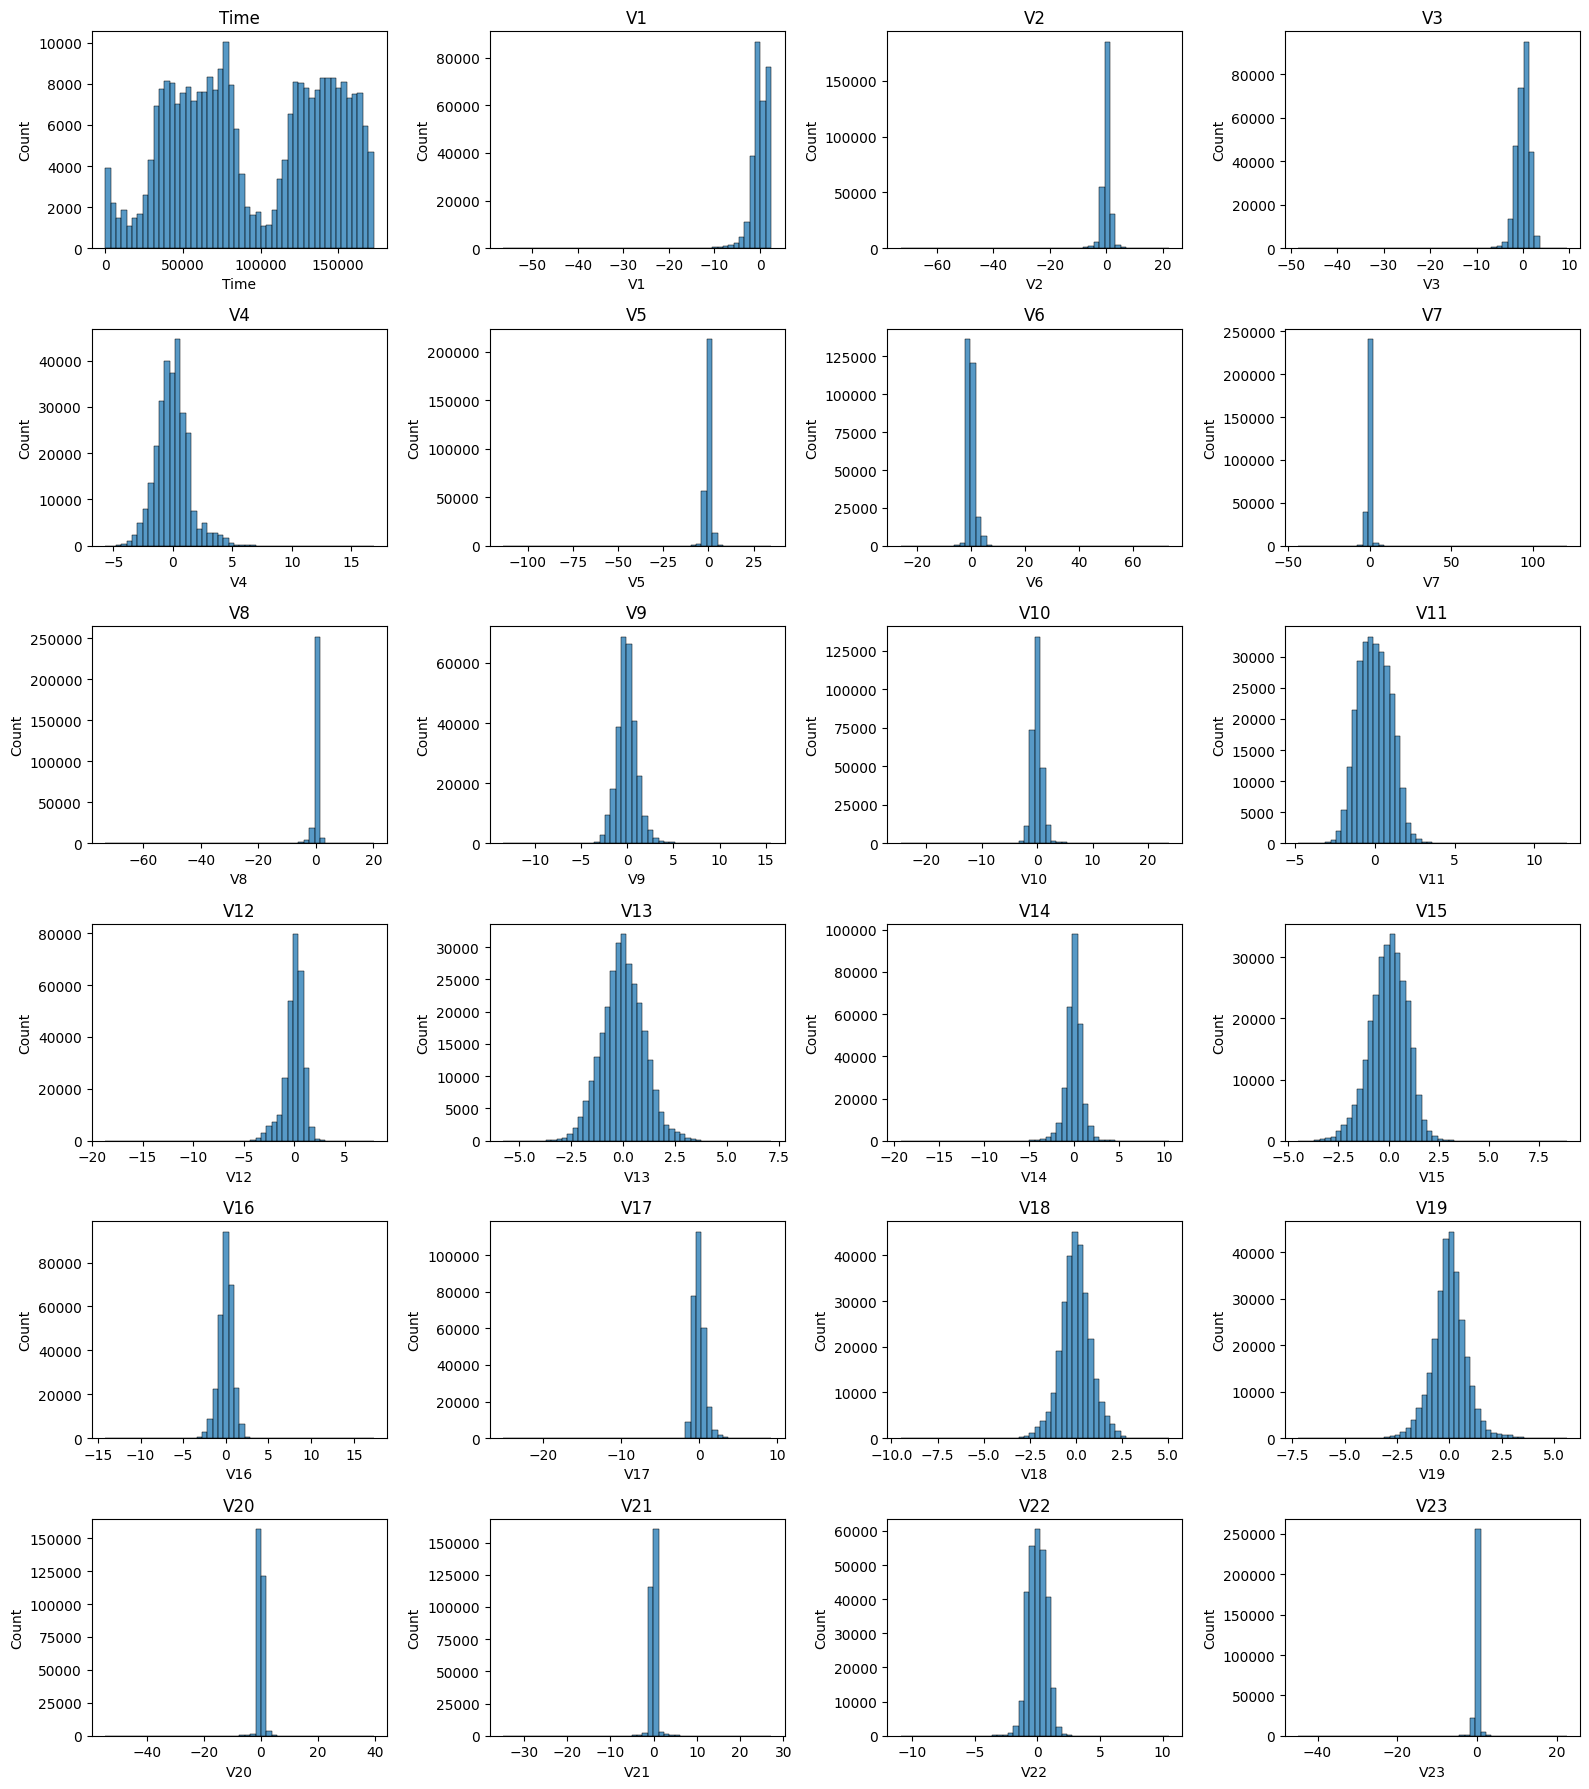

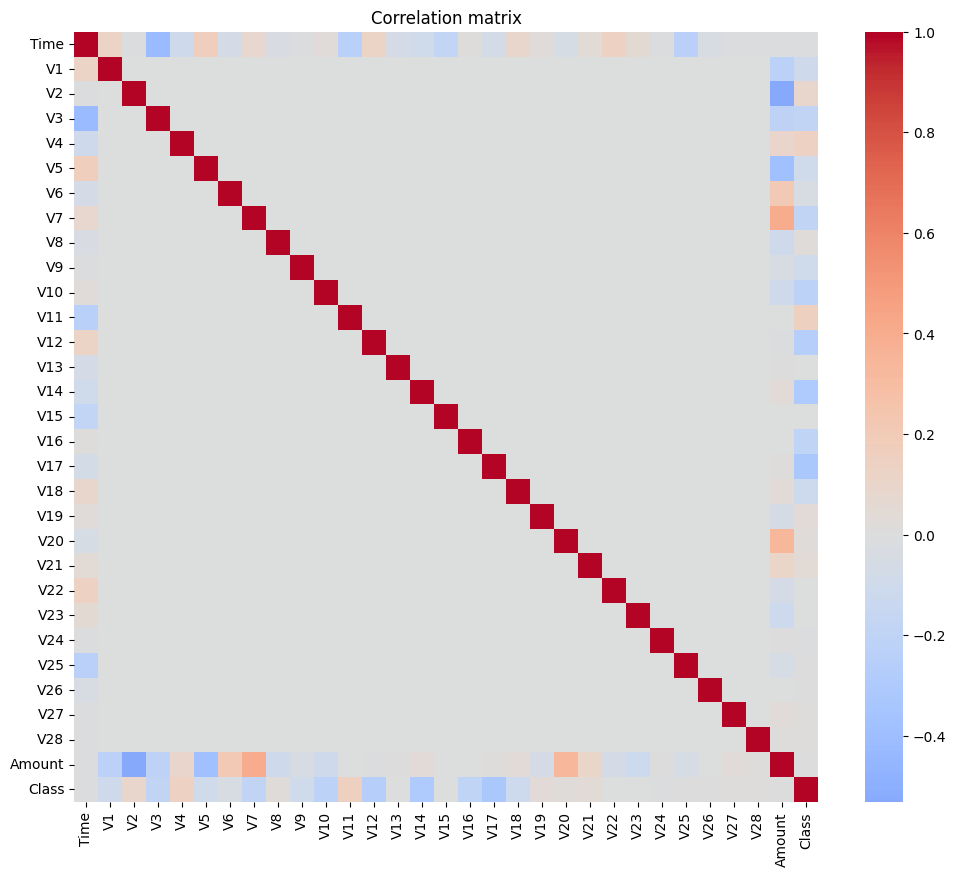

In [3]:
# Visualizations: distributions and correlation

num = df.select_dtypes(include=[np.number])

# Histograms (sample columns if too many)
cols_to_plot = num.columns.tolist()
max_cols = 24
if len(cols_to_plot) > max_cols:
    cols_to_plot = cols_to_plot[:max_cols]

fig, axes = plt.subplots(nrows=int(np.ceil(len(cols_to_plot)/4)), ncols=4, figsize=(16, 3 * int(np.ceil(len(cols_to_plot)/4))))
for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(cols_to_plot):]:
    ax.set_visible(False)
plt.tight_layout()

# Correlation heatmap for numeric features (if not too many)
if num.shape[1] <= 60:
    plt.figure(figsize=(12, 10))
    sns.heatmap(num.corr(), cmap='coolwarm', center=0)
    plt.title('Correlation matrix')
else:
    print('Too many numeric columns for full correlation heatmap — consider selecting features')

plt.show()

In [4]:
# Cleaning & feature engineering

def clean_and_engineer(df):
    df = df.copy()
    # drop fully empty columns
    empty_cols = [c for c in df.columns if df[c].isna().all()]
    if empty_cols:
        print('dropping empty columns:', empty_cols)
        df.drop(columns=empty_cols, inplace=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

    # impute numerics with median
    for c in num_cols:
        if df[c].isna().any():
            df[c].fillna(df[c].median(), inplace=True)

    # impute categoricals with mode
    for c in cat_cols:
        if df[c].isna().any():
            df[c].fillna(df[c].mode().iloc[0], inplace=True)

    # feature: log-transform Amount if present
    if 'Amount' in df.columns:
        df['Amount_log1p'] = np.log1p(df['Amount'].abs())

    return df

# apply
df_clean = clean_and_engineer(df)
print('after cleaning shape:', df_clean.shape)

# brief compare
print('missing values after cleaning (top):')
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

df_clean.head()

after cleaning shape: (284807, 32)
missing values after cleaning (top):
Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log1p
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539


In [5]:
# Scaling, train/test split, and class weights

# select target and features
if 'Class' not in df_clean.columns:
    raise RuntimeError("Expected column 'Class' as target")

X = df_clean.drop(columns=['Class'])
# one-hot encode categoricals if any
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

y = df_clean['Class'].astype(int)

# scale features
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# stratified split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# compute class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print('train shape:', X_train.shape, 'test shape:', X_test.shape)
print('train target counts:')
print(y_train.value_counts())
print('\nclass_weights:', class_weights)

train shape: (227845, 31) test shape: (56962, 31)
train target counts:
Class
0    227451
1       394
Name: count, dtype: int64

class_weights: {0: 0.5008661206149896, 1: 289.14340101522845}


## Livrable 2 : Modélisation et optimisation

Plan de cette étape :

1. Initialiser MLflow pour suivre les expériences.
2. Entraîner plusieurs modèles adaptés à la classification déséquilibrée.
3. Comparer les modèles sur des métriques pertinentes.
4. Sélectionner le meilleur modèle et l'enregistrer.

Les métriques retenues sont : **precision**, **recall**, **F1**, **ROC-AUC** et **PR-AUC**. La **PR-AUC** est particulièrement adaptée à la détection de fraude car elle valorise la précision sur la classe minoritaire.


### 2.1 Suivi des expériences avec MLflow

MLflow permet de :

- consigner les paramètres et les métriques de chaque modèle,
- comparer facilement les performances,
- enregistrer les modèles pour la réutilisation ultérieure.

Ce suivi est important pour documenter le choix final et fournir des preuves claires des tests effectués.


In [6]:
import mlflow
import mlflow.sklearn


In [7]:
# check the tracking URI and experiment
print('MLflow tracking URI:', mlflow.get_tracking_uri())

MLflow tracking URI: sqlite:////workspaces/Projet-encadre/mlflow.db


In [8]:
mlflow.tracking.set_tracking_uri("http://localhost:5000")

In [9]:
mlflow.get_tracking_uri()

'http://localhost:5000'

In [10]:
#import classifiers and metrics for modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [11]:
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')

# Helper function for evaluation
def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    """Train and evaluate model with comprehensive metrics"""
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)
    roc_auc = roc_auc_score(y_test_data, y_pred_proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_data, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    return model, y_pred, y_pred_proba, metrics

# Store results
results = {}

# Model 1: Random Forest with class weights (baseline)
print("=" * 60)
print("Model 1: Random Forest with class weights")
print("=" * 60)

with mlflow.start_run(run_name="1-random-forest-class-weight") as run:
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_type", "original")
    
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_model, rf_pred, rf_proba, rf_metrics = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "RF")
    
    for metric, value in rf_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(rf_model, "model")
    results["Random Forest"] = rf_metrics

Model 1: Random Forest with class weights


Precision: 0.9186
Recall: 0.8061
F1: 0.8587
ROC-AUC: 0.9674


2026/06/11 11:11:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:11:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8784


2026/06/11 11:11:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:11:44 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:11:44 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:11:44 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:11:44 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:11:50 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 1-random-forest-class-weight at: http://localhost:5000/#/experiments/0/runs/bb1368247ec64c458a3b3ff2b3a8132f
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [12]:
# Model 2: Logistic Regression with class weights (baseline linear model)
print("\n" + "=" * 60)
print("Model 2: Logistic Regression with class weights")
print("=" * 60)

with mlflow.start_run(run_name="2-logistic-regression") as run:
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("data_type", "original")
    
    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
    lr_model, lr_pred, lr_proba, lr_metrics = evaluate_model(lr_model, X_train, y_train, X_test, y_test, "LR")
    
    for metric, value in lr_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(lr_model, "model")
    results["Logistic Regression"] = lr_metrics


Model 2: Logistic Regression with class weights


Precision: 0.0614
Recall: 0.9184
F1: 0.1152
ROC-AUC: 0.9718


2026/06/11 11:11:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:11:58 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.7644


2026/06/11 11:11:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:11:58 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:11:58 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:11:59 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:11:59 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:11:59 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 2-logistic-regression at: http://localhost:5000/#/experiments/0/runs/761945652c044a9ca47ca65777820387
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [13]:
# Model 3: Gradient Boosting Classifier
print("\n" + "=" * 60)
print("Model 3: Gradient Boosting Classifier")
print("=" * 60)

from sklearn.ensemble import GradientBoostingClassifier

with mlflow.start_run(run_name="3-gradient-boosting") as run:
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("data_type", "original")
    
    gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model, gb_pred, gb_proba, gb_metrics = evaluate_model(gb_model, X_train, y_train, X_test, y_test, "GB")
    
    for metric, value in gb_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(gb_model, "model")
    results["Gradient Boosting"] = gb_metrics


Model 3: Gradient Boosting Classifier
Precision: 0.7975
Recall: 0.6429
F1: 0.7119
ROC-AUC: 0.7418


2026/06/11 11:20:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:20:04 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.5857


2026/06/11 11:20:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:20:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:20:05 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:20:05 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:20:05 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:20:05 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 3-gradient-boosting at: http://localhost:5000/#/experiments/0/runs/bff60a5706a64f60b3732ff20cb3d520
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [14]:
# Model 4: Extra Trees Classifier
print("\n" + "=" * 60)
print("Model 4: Extra Trees Classifier")
print("=" * 60)

from sklearn.ensemble import ExtraTreesClassifier

with mlflow.start_run(run_name="4-extra-trees") as run:
    mlflow.log_param("model_type", "ExtraTrees")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_type", "original")
    
    et_model = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    et_model, et_pred, et_proba, et_metrics = evaluate_model(et_model, X_train, y_train, X_test, y_test, "ET")
    
    for metric, value in et_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(et_model, "model")
    results["Extra Trees"] = et_metrics


Model 4: Extra Trees Classifier
Precision: 0.9512
Recall: 0.7959
F1: 0.8667
ROC-AUC: 0.9526


2026/06/11 11:20:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:20:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8886


2026/06/11 11:20:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:20:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:20:24 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:20:24 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:20:24 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:20:24 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 4-extra-trees at: http://localhost:5000/#/experiments/0/runs/43993992477b4a13b3aab454a8a0cabd
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [15]:
# Model 5: XGBoost Classifier
print("\n" + "=" * 60)
print("Model 5: XGBoost Classifier")
print("=" * 60)

try:
    import xgboost as xgb
    
    # Calculate scale_pos_weight for imbalanced data
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    
    with mlflow.start_run(run_name="5-xgboost") as run:
        mlflow.log_param("model_type", "XGBoost")
        mlflow.log_param("n_estimators", 100)
        mlflow.log_param("max_depth", 6)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)
        mlflow.log_param("data_type", "original")
        
        xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight, 
                                       random_state=42, n_jobs=-1, verbosity=0)
        xgb_model, xgb_pred, xgb_proba, xgb_metrics = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGB")
        
        for metric, value in xgb_metrics.items():
            mlflow.log_metric(metric, value)
            print(f"{metric}: {value:.4f}")
        
        mlflow.sklearn.log_model(xgb_model, "model")
        results["XGBoost"] = xgb_metrics
except ImportError:
    print("XGBoost not installed, skipping this model")


Model 5: XGBoost Classifier
Precision: 0.8817
Recall: 0.8367
F1: 0.8586
ROC-AUC: 0.9682


2026/06/11 11:20:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:20:30 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8799


2026/06/11 11:20:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:20:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:20:31 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:20:31 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:20:31 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:20:31 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 5-xgboost at: http://localhost:5000/#/experiments/0/runs/187f7bbc06ec43c99c15f2853db3286b
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [16]:
# Model 6: LightGBM Classifier
print("\n" + "=" * 60)
print("Model 6: LightGBM Classifier")
print("=" * 60)

try:
    import lightgbm as lgb
    
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    
    with mlflow.start_run(run_name="6-lightgbm") as run:
        mlflow.log_param("model_type", "LightGBM")
        mlflow.log_param("n_estimators", 100)
        mlflow.log_param("max_depth", 6)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)
        mlflow.log_param("data_type", "original")
        
        lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight,
                                        random_state=42, n_jobs=-1, verbosity=-1)
        lgb_model, lgb_pred, lgb_proba, lgb_metrics = evaluate_model(lgb_model, X_train, y_train, X_test, y_test, "LGB")
        
        for metric, value in lgb_metrics.items():
            mlflow.log_metric(metric, value)
            print(f"{metric}: {value:.4f}")
        
        mlflow.sklearn.log_model(lgb_model, "model")
        results["LightGBM"] = lgb_metrics
except ImportError:
    print("LightGBM not installed, skipping this model")


Model 6: LightGBM Classifier
Precision: 0.0319
Recall: 0.8673
F1: 0.0615
ROC-AUC: 0.9031


2026/06/11 11:20:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:20:36 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.4460


2026/06/11 11:20:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:20:37 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:20:37 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:20:37 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:20:37 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:20:37 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 6-lightgbm at: http://localhost:5000/#/experiments/0/runs/d57bf670ec56494ea6bafb6525deb776
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [17]:
# Model 7: AdaBoost Classifier
print("\n" + "=" * 60)
print("Model 7: AdaBoost Classifier")
print("=" * 60)

from sklearn.ensemble import AdaBoostClassifier

with mlflow.start_run(run_name="7-adaboost") as run:
    mlflow.log_param("model_type", "AdaBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.8)
    mlflow.log_param("data_type", "original")
    
    # AdaBoost with Decision Tree base estimator
    from sklearn.tree import DecisionTreeClassifier
    ada_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, 
                                    learning_rate=0.8, random_state=42)
    ada_model, ada_pred, ada_proba, ada_metrics = evaluate_model(ada_model, X_train, y_train, X_test, y_test, "Ada")
    
    for metric, value in ada_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(ada_model, "model")
    results["AdaBoost"] = ada_metrics


Model 7: AdaBoost Classifier


Precision: 0.9167
Recall: 0.7857
F1: 0.8462
ROC-AUC: 0.9712


2026/06/11 11:25:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 11:25:46 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8568


2026/06/11 11:25:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 11:25:46 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 11:25:46 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 11:25:46 INFO mlflow.utils.uv_utils: Exported 183 dependencies via uv
2026/06/11 11:25:46 INFO mlflow.utils.environment: Successfully exported 183 requirements from uv project. Skipping package capture based inference.
2026/06/11 11:25:47 WARNING mlflow.utils.requirements_utils: Detected one or more mi

🏃 View run 7-adaboost at: http://localhost:5000/#/experiments/0/runs/662e6b3a56964812a65cab1a5cac7fe6
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [21]:

# Results Summary: Compare all 7 models

results_df = pd.DataFrame(results).T
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results_df.round(4))

# Find best models by each metric
print("\n" + "=" * 80)
print("BEST MODELS BY METRIC")
print("=" * 80)
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"{metric:12} → {best_model:20} ({best_score:.4f})")

# Recommend best overall (by PR-AUC, which is best for imbalanced classification)
best_model_name = results_df['PR-AUC'].idxmax()
best_pr_auc = results_df['PR-AUC'].max()

print("\n" + "=" * 80)
print(f"BEST MODEL: {best_model_name}")
print(f"   PR-AUC: {best_pr_auc:.4f} (best metric for imbalanced fraud detection)")
print(f"   Full metrics: {results_df.loc[best_model_name].to_dict()}")
print("=" * 80)



MODEL COMPARISON SUMMARY
                     Precision  Recall      F1  ROC-AUC  PR-AUC
Random Forest           0.9186  0.8061  0.8587   0.9674  0.8784
Logistic Regression     0.0614  0.9184  0.1152   0.9718  0.7644
Gradient Boosting       0.7975  0.6429  0.7119   0.7418  0.5857
Extra Trees             0.9512  0.7959  0.8667   0.9526  0.8886
XGBoost                 0.8817  0.8367  0.8586   0.9682  0.8799
LightGBM                0.0319  0.8673  0.0615   0.9031  0.4460
AdaBoost                0.9167  0.7857  0.8462   0.9712  0.8568

BEST MODELS BY METRIC
Precision    → Extra Trees          (0.9512)
Recall       → Logistic Regression  (0.9184)
F1           → Extra Trees          (0.8667)
ROC-AUC      → Logistic Regression  (0.9718)
PR-AUC       → Extra Trees          (0.8886)

BEST MODEL: Extra Trees
   PR-AUC: 0.8886 (best metric for imbalanced fraud detection)
   Full metrics: {'Precision': 0.9512195121951219, 'Recall': 0.7959183673469388, 'F1': 0.8666666666666667, 'ROC-AUC': 0.952634

In [20]:

# Save the best model

import pickle
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Select the best model based on PR-AUC
best_model_obj = {
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'Gradient Boosting': gb_model,
    'Extra Trees': et_model,
    'XGBoost': xgb_model if 'xgb_model' in locals() else None,
    'LightGBM': lgb_model if 'lgb_model' in locals() else None,
    'AdaBoost': ada_model
}

best_model = best_model_obj[best_model_name]

# Save with pickle
model_path = f"models/{best_model_name.lower().replace(' ', '_')}_best_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Best model saved: {model_path}")
print(f"   Model: {best_model_name}")
print(f"   PR-AUC: {best_pr_auc:.4f}")
print(f"   File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Also save the scaler for preprocessing new data
scaler_path = "models/robust_scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Feature scaler saved: {scaler_path}")


Best model saved: models/extra_trees_best_model.pkl
   Model: Extra Trees
   PR-AUC: 0.8886
   File size: 14.85 MB
Feature scaler saved: models/robust_scaler.pkl


## Livrable 3 : Visualisation et interprétation des résultats

Plan de cette étape :

1. Visualiser les résultats du modèle retenu.
2. Interpréter la matrice de confusion, la courbe PR et la courbe ROC.
3. Vérifier la qualité de la détection des fraudes.
4. Fournir une conclusion claire et structurée.

Cette section montre comment le modèle se comporte et pourquoi il a été retenu.


<Figure size 600x500 with 0 Axes>

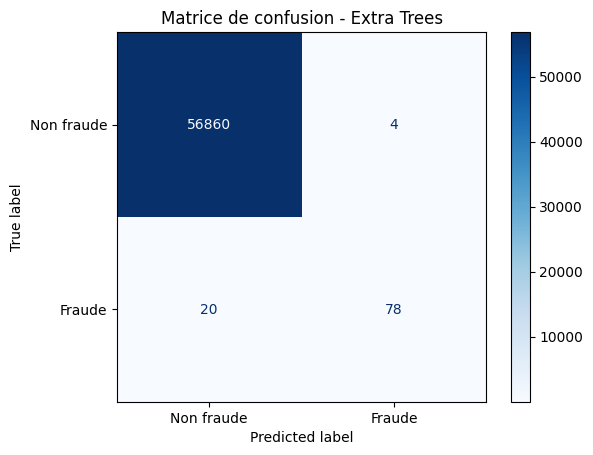

<Figure size 700x500 with 0 Axes>

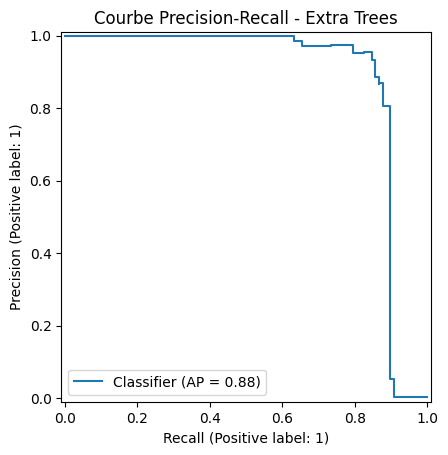

<Figure size 700x500 with 0 Axes>

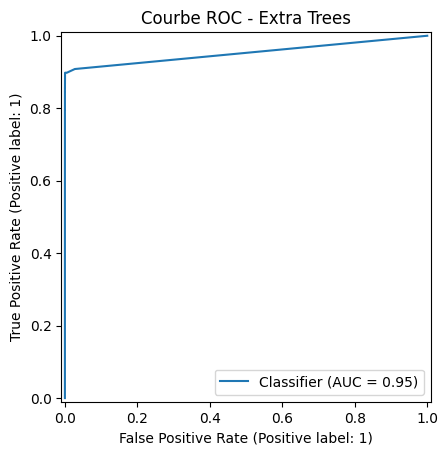

Classification report:
              precision    recall  f1-score   support

  Non fraude       1.00      1.00      1.00     56864
      Fraude       0.95      0.80      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [22]:
# Visualisation et interprétation des résultats pour le modèle retenu

from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

# Charger le meilleur modèle si nécessaire
best_model = et_model

# Prédictions
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

# Afficher matrice de confusion
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, cmap='Blues', display_labels=['Non fraude', 'Fraude'])
plt.title('Matrice de confusion - Extra Trees')
plt.show()

# Courbe PR
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, best_proba)
plt.title('Courbe Precision-Recall - Extra Trees')
plt.show()

# Courbe ROC
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title('Courbe ROC - Extra Trees')
plt.show()

# Afficher les métriques importantes de nouveau pour interprétation
from sklearn.metrics import classification_report
print('Classification report:')
print(classification_report(y_test, best_pred, target_names=['Non fraude', 'Fraude']))


### Analyse des graphiques et interprétation

- **Matrice de confusion** : elle montre le nombre de vrais positifs, faux positifs, vrais négatifs et faux négatifs. L'objectif est de détecter un maximum de fraudes sans générer trop de faux positifs.
- **Courbe Precision-Recall** : elle est prioritaire pour ce dataset déséquilibré. Une bonne courbe PR montre que le modèle garde un bon équilibre entre précision et rappel.
- **Courbe ROC** : elle illustre la capacité du modèle à séparer les classes. Une aire sous la courbe proche de 1 indique une bonne discrimination.
- **Classification report** : il récapitule la précision, le rappel et le F1-score pour chaque classe et permet de vérifier la performance sur les cas de fraude.

Ces éléments sont essentiels pour interpréter le comportement réel du modèle.


## Livrable 4 : Validation des résultats et conclusion

Plan de cette étape :

1. Valider la robustesse du modèle retenu avec une validation croisée.
2. Mesurer la stabilité des métriques sur plusieurs plis.
3. Conclure sur le choix du modèle et les prochaines étapes.

La validation croisée stratifiée permet de vérifier que la performance n'est pas due à un hasard de découpage des données.


In [24]:
# Validation croisée du modèle retenu et robustesse

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(best_model, X_scaled, y, cv=cv, scoring=scoring, n_jobs=-1)

cv_summary = { metric: (cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()) for metric in scoring }
print('Cross-validation results (mean ± std):')
for metric, (mean_score, std_score) in cv_summary.items():
    print(f"- {metric:12}: {mean_score:.4f} ± {std_score:.4f}")


Cross-validation results (mean ± std):
- precision   : 0.9579 ± 0.0265
- recall      : 0.7765 ± 0.0162
- f1          : 0.8575 ± 0.0163
- roc_auc     : 0.9527 ± 0.0030
- average_precision: 0.8566 ± 0.0217
